In [2]:
import pandas as pd
import json
from pathlib import Path
import requests
import os
import glob

In [3]:
# Load the provinces data from the tat_thai_provinces.json file
with open('../../dataset/tat_v1_provinces.json', 'r', encoding='utf-8') as f:
    provinces = json.load(f)

# API key for authentication
API_KEY = 'UmYQ8yiaTyArXEN5GMRJiCcvtu99ILDd'

# API Key for tripadvisor
TRIPADVISOR_API_KEY = 'FDB8183A632245CDA0EC0DBF74159030'

# Base URL for fetching attractions list
BASE_URL = 'https://tatdataapi.io/api/v1/places'

TRIPADVISOR_BASE_URL = 'https://api.content.tripadvisor.com/api/v1/location'

LANGUAGE = 'en'

# Headers for the API request
headers = {
    'accept': 'application/json',
    'Accept-Language': LANGUAGE,
    'x-api-key': API_KEY,
}


In [ ]:
# Loop through each province and fetch the data
for province in provinces:
    province_id = province['provinceId']
    province_name = province['name']
    
    # Prepare the parameters for the API request
    params = {
        'provinceId': province_id,
        # 'place_category_id': 3,  # You can change this if necessary
        'pageSize': 100, # For V1
        # 'page': 1,
        'pageNumber': 1, # For V1
        # 'sort_by': 'placeId',
        # 'categoryCode': 'attractions' # For V2
        'categoryCode': 'attraction' # For V1
    }
    
    # Send the GET request to fetch the attractions
    response = requests.get(BASE_URL, headers=headers, params=params)
    
    if response.status_code == 200:
        # Convert the response to JSON
        data = response.json()
        
        # Check if 'data' is available in the response
        if 'data' in data:
            attractions = data['data']
            
            # Transform the data into a DataFrame
            records = []
            for item in attractions:
                location = item.get("location", {})
                tags = item.get("tags", [])
                category = item.get("category", {})
                province = location.get("province", {})
                district = location.get("district", {})
                sub_district = location.get("subDistrict", {})
                
                record = {
                    "placeId": item.get("placeId"),
                    "place_name": item.get("name"),
                    "introduction": item.get("introduction"),
                    "category_name": category.get("name"),
                    "categoryId": category.get("categoryId"),
                    "latitude": item.get("latitude"),
                    "longitude": item.get("longitude"),
                    "postcode": location.get("postcode") if location else None,
                    "thumbnail_url": item.get("thumbnailUrl", [None])[0] if item.get("thumbnailUrl") else None,
                    "tags": ",".join(tags) if tags else "",  # Safely handle tags
                    "province_Id": province.get("provinceId") if province else None,
                    "province_name": province.get("name") if province else None,
                    "district_Id": district.get("districtId") if district else None,
                    "district_name": district.get("name") if district else None,
                    "sub_district_Id": sub_district.get("subDistrictId") if sub_district else None,
                    "sub_district_name": sub_district.get("name") if sub_district else None,
                    "updated_at": item.get("updatedAt"),
                }
                records.append(record)
            
            # Create a DataFrame
            df = pd.DataFrame(records)
            
            # Save the DataFrame to a CSV file
            csv_filename = f"data/{province_id}_attractions_{LANGUAGE}.csv"
            df.to_csv(csv_filename, index=False, encoding='utf-8')
            print(f"Data for {province_name} saved to {csv_filename}")
        else:
            print(f"No data found for {province_name} (ID: {province_id})")
    else:
        print(f"Failed to fetch data for {province_name} (ID: {province_id})")

In [ ]:
# Directory where the CSV files are stored (you can set this to the path where your CSV files are)
csv_directory = './data/'  # Assuming the files are in the current working directory

# Initialize an empty list to hold DataFrames
df_list = []

# Loop through all CSV files in the directory
for filename in os.listdir(csv_directory):
    if filename.endswith(f"_attractions_{LANGUAGE}.csv"):  # Only process the relevant CSV files
        file_path = os.path.join(csv_directory, filename)
        
        # Read each CSV file into a DataFrame and append it to the list
        df = pd.read_csv(file_path)
        df_list.append(df)

# Concatenate all DataFrames into one
merged_df = pd.concat(df_list, ignore_index=True)

# Save the merged DataFrame to a single CSV file
merged_df.to_csv(f"tat_attractions_{LANGUAGE}.csv", index=False, encoding='utf-8')

print(f"All files have been merged into 'tat_attractions_{LANGUAGE}.csv'")

In [5]:
# Define the path to the JSON file
json_file = Path("../../dataset/tat_attractions.json")

# Check if the file exists
if not json_file.is_file():
    raise FileNotFoundError(f"The file '{json_file}' does not exist. Please provide the correct file path.")

# Load the JSON file
with json_file.open('r', encoding='utf-8') as file:
    data = json.load(file)

In [7]:

records = []
for item in data['data']:  # Added safeguard for 'data' key
    if not item:  # Ensure item is not None or empty
        continue
    
    location = item.get("location", {})  # Safe way to access location, defaults to empty dict if None
    tags = item.get("tags", [])  # Ensure tags defaults to an empty list
    category = item.get("category", {})  # Ensure category defaults to an empty dict
    province = location.get("province", {})  # Safely get province
    district = location.get("district", {})  # Safely get district
    sub_district = location.get("subDistrict", {})  # Safely get subDistrict
    
    record = {
        "placeId": item.get("placeId"),
        "place_name": item.get("name"),
        "introduction": item.get("introduction"),
        "category_name": category.get("name"),  # Safely access category name
        "categoryId": category.get("categoryId"),  # Safely access category ID
        "latitude": item.get("latitude"),
        "longitude": item.get("longitude"),
        "postcode": location.get("postcode") if location else None,
        "thumbnail_url": item.get("thumbnailUrl", [None])[0] if item.get("thumbnailUrl") else None,
        "tags": ",".join(tags) if tags else "",  # Safely handle tags and avoid errors when None
        "province_Id": province.get("provinceId") if province else None,  # Safely get province ID
        "province_name": province.get("name") if province else None,  # Safely get province name
        "district_Id": district.get("districtId") if district else None,  # Safely get district ID
        "district_name": district.get("name") if district else None,  # Safely get district name
        "sub_district_Id": sub_district.get("subDistrictId") if sub_district else None,  # Safely get sub-district ID
        "sub_district_name": sub_district.get("name") if sub_district else None,  # Safely get sub-district name
        "updated_at": item.get("updatedAt"),
    }
    records.append(record)

# Create a DataFrame from the extracted records
df = pd.DataFrame(records)

# Save the DataFrame to a CSV file (optional)
df.to_csv("tat_attractions.csv", index=False, encoding='utf-8')

# Display the DataFrame to verify
print(df.head())

  placeId                             place_name  \
0    1858  วัดสระเกศ ราชวรมหาวิหาร (วัดภูเขาทอง)   
1   33400               ศาลเจ้าพ่อ-เจ้าแม่ชุมแสง   
2   33586                   ตลาดเก่าร้อยปีชุมแสง   
3   33885                            ตลาดเจ้าค่ะ   
4   33325                 อุทยานเทวสถานพระพิฆเนศ   

                                        introduction      category_name  \
0  วัดสระเกศ หรือ วัดภูเขาทอง (Temple of the Gold...  สถานที่ท่องเที่ยว   
1                                               None  สถานที่ท่องเที่ยว   
2                                               None  สถานที่ท่องเที่ยว   
3  ตั้งอยู่ตำบลเขาดิน บริเวณริมแม่น้ำปิงด้านหน้าว...  สถานที่ท่องเที่ยว   
4                                               None  สถานที่ท่องเที่ยว   

   categoryId  latitude  longitude postcode  \
0           3  13.75389  100.50841    10100   
1           3  15.89933  100.30886    60120   
2           3  15.89541  100.30847    60120   
3           3  15.81700  100.07715    60230   
4

In [6]:
EN_Attractions_df = pd.read_csv('./tat_attractions_en.csv')
TH_Attractions_df = pd.read_csv('./tat_attractions_th.csv')

In [7]:
TH_Attractions_df.head(5)

,placeId,place_name,introduction,category_name,categoryId,latitude,longitude,postcode,thumbnail_url,tags,province_Id,province_name,district_Id,district_name,sub_district_Id,sub_district_name,updated_at
0,P03012583,ถ้ำมโหฬาร,อยู่ที่บ้านหนองหิน ตำบลหนองหิน อยู่ในบริเวณวัด...,สถานที่ท่องเที่ยว,3,17.10731,101.87997,42190.0,h,NaN,576,เลย,4214.0,หนองหิน,5102.0,หนองหิน,2024-07-16T20:03:56.009Z
1,P03014048,เสมาหินทราย บ้านปากแบ่งและบ้านนาหลัก,ที่บ้านนาหลัก เป็นเสมาหินปักคู่สองหลัก แบบที่ม...,สถานที่ท่องเที่ยว,3,17.48602,101.72230,42000.0,h,NaN,576,เลย,4201.0,เมืองเลย,4994.0,กุดป่อง,2024-07-16T20:03:55.442Z
2,P03025545,ศูนย์บริการนักท่องเที่ยววังกวาง,เป็นลานกางเต็นท์และบ้านพักของอุทยานฯ ซึ่งตั้งอ...,สถานที่ท่องเที่ยว,3,16.88681,101.78800,42180.0,h,NaN,576,เลย,4210.0,ภูกระดึง,5076.0,ศรีฐาน,2024-07-16T20:03:51.616Z
3,P03012596,อุทยานแห่งชาติภูสวนทราย,เป็นป่าดิบเขาเป็นพรมแดนธรรมชาติระหว่างแผ่นดินไ...,สถานที่ท่องเที่ยว,3,17.50356,100.93892,42170.0,h,อุทยานแห่งชาติภูสวนทราย,576,เลย,4206.0,นาแห้ว,5044.0,แสงภา,2024-07-16T20:03:51.358Z
4,P03001063,วัดท่าแขก วัดโบราณ,เป็นวัดเก่าแก่อยู่ริมฝั่งแม่น้ำโขง ห่างจากอำเภ...,สถานที่ท่องเที่ยว,3,17.90506,101.68336,42110.0,h,NaN,576,เลย,4203.0,เชียงคาน,5012.0,เชียงคาน,2024-07-16T20:03:50.031Z


In [8]:
EN_Attractions_df.head(5)

,placeId,place_name,introduction,category_name,categoryId,latitude,longitude,postcode,thumbnail_url,tags,province_Id,province_name,district_Id,district_name,sub_district_Id,sub_district_name,updated_at
0,P03018449,Old Town by Phetchaburi’s River CBT,NaN,Attraction,3,13.10722,99.94842,76000.0,h,"เพชรบุรี,ย่านเมืองเก่า",228,Phetchaburi,7601.0,Mueang Phetchaburi,8421.0,Khlong Krachaeng,2024-08-01T20:00:06.292Z
1,P03013153,Kwangchow Floating Market,NaN,Attraction,3,13.11103,99.63627,76160.0,h,NaN,228,Phetchaburi,7603.0,Nong Ya Plong,8459.0,Yang Nam Klat Nuea,2024-07-16T20:03:55.831Z
2,P03014487,Wat Khoi,NaN,Attraction,3,13.10870,99.94154,76000.0,h,"พระธาตุฉิมพลีพระเศรษฐีนวโกฏิ ,เพชรบุรี,วัดข่อย",228,Phetchaburi,7601.0,Mueang Phetchaburi,8421.0,Khlong Krachaeng,2024-07-16T20:03:50.833Z
3,P03013393,Hat Chao Samran,"This beach, which is located approximately 15 ...",Attraction,3,13.00624,100.06602,76100.0,h,NaN,228,Phetchaburi,7601.0,Mueang Phetchaburi,8436.0,Hat Chao Samran,2024-07-16T20:03:47.548Z
4,P03008661,Laem Leaw,NaN,Attraction,3,13.22476,99.99306,76110.0,h,NaN,228,Phetchaburi,7607.0,Ban Laem,8510.0,Ban Laem,2024-07-16T20:03:42.554Z


In [9]:
TH_Attractions_df['placeId'] = TH_Attractions_df['placeId'].astype(str)
EN_Attractions_df['placeId'] = EN_Attractions_df['placeId'].astype(str)

TH_Attractions_df.rename(columns={'introduction': 'introduction_th'}, inplace=True)
TH_Attractions_df.rename(columns={'place_name': 'place_name_th'}, inplace=True)
TH_Attractions_df.rename(columns={'province_name': 'province_name_th'}, inplace=True)
TH_Attractions_df.rename(columns={'district_name': 'district_name_th'}, inplace=True)
TH_Attractions_df.rename(columns={'sub_district_name': 'sub_district_name_th'}, inplace=True)
Merge_Attractions_df = TH_Attractions_df.merge(EN_Attractions_df[['placeId', 'introduction', 'place_name', 'province_name', 'district_name', 'sub_district_name']], on='placeId', how='left')
Merge_Attractions_df.rename(columns={'introduction': 'introduction_en'}, inplace=True)
Merge_Attractions_df.rename(columns={'place_name': 'place_name_en'}, inplace=True)
Merge_Attractions_df.rename(columns={'province_name': 'province_name_en'}, inplace=True)
Merge_Attractions_df.rename(columns={'district_name': 'district_name_en'}, inplace=True)
Merge_Attractions_df.rename(columns={'sub_district_name': 'sub_district_name_en'}, inplace=True)

Merge_Attractions_df['introduction_en'].fillna('-')
Merge_Attractions_df['introduction_th'].fillna('-')

0       อยู่ที่บ้านหนองหิน ตำบลหนองหิน อยู่ในบริเวณวัด...
1       ที่บ้านนาหลัก เป็นเสมาหินปักคู่สองหลัก แบบที่ม...
2       เป็นลานกางเต็นท์และบ้านพักของอุทยานฯ ซึ่งตั้งอ...
3       เป็นป่าดิบเขาเป็นพรมแดนธรรมชาติระหว่างแผ่นดินไ...
4       เป็นวัดเก่าแก่อยู่ริมฝั่งแม่น้ำโขง ห่างจากอำเภ...
                              ...                        
4320                                                    -
4321    ประดิษฐาน "พระบาง" พระพุทธรูปสำคัญคู่บ้านคู่เม...
4322                                                    -
4323                                                    -
4324                                                    -
Name: introduction_th, Length: 4325, dtype: object

In [ ]:
Merge_Attractions_df.info()

In [ ]:
Merge_Attractions_df.head(5)

In [ ]:
Merge_Attractions_df.to_csv('./merged_tat_attractions.csv', index=False, encoding='utf-8')

In [10]:
Merge_Attractions_df = pd.read_csv("./merged_tat_attractions.csv")

In [ ]:
Merge_Attractions_df.info()

In [17]:

def fetch_tripvisor_attractions(attraction_df, filter_df = []):
    records = []
    
    for index, attraction in attraction_df.iterrows():
        if len(filter_df) > 0 and attraction.placeId in filter_df["place_id"].values:
            continue
        
        # Handle language-specific fields
        province_name = attraction.province_name_th
        place_name = attraction.place_name_th
        latLong = f"{attraction.latitude}, {attraction.longitude}"
        address = 'Thailand'
        # address = f"{attraction.province_name_th} {attraction.district_name_th} {attraction.sub_district_name_th} {attraction.postcode}"
        if LANGUAGE == 'en':
            province_name = attraction.province_name_en or province_name
            place_name = attraction.place_name_en or place_name
            
            
        print(f"\n #{index + 1} ===== Processing attraction: {place_name} in province {province_name} [{latLong}] [{address}]")

        # Prepare the parameters for the API request
        params = {
            'key': TRIPADVISOR_API_KEY,
            'searchQuery': place_name,
            'language': LANGUAGE,
            'address': address,
            'category': 'attractions',
            # 'latLong': latLong
        }

        try:
            # Send the GET request to fetch the attractions
            response = requests.get(f"{TRIPADVISOR_BASE_URL}/search", headers=headers, params=params)

            # Debug: Print request and response details
            print(f"Request URL: {response.url}")
            print(f"Response Status Code: {response.status_code}")
            
            # Stop loop on critical error (status codes in 4xx or 5xx range)
            if response.status_code >= 400:
                print(f"Critical error encountered! Status code: {response.status_code}")
                # break

            if response.status_code == 200:
                # Convert the response to JSON
                data = response.json()
                print(f"Response Content: {data}")  # Debug: Print the full JSON response

                # Check if 'data' is available in the response
                if 'data' in data and data['data']:
                    attractions = data['data']

                    # Process attractions
                    for item in attractions:
                        
                        if len(filter_df) > 0 and  item.get("location_id") in filter_df["location_id"].values:
                            continue
    
                        addressObj = item.get("address_obj", {})
                        record = {
                            "place_id": attraction.placeId,
                            "location_id": item.get("location_id"),
                            "name": item.get("name"),
                            "state": addressObj.get("postalcode") if addressObj.get("state") else pd.NA,
                            "country": addressObj.get("country"),
                            "postalcode": addressObj.get("postalcode") if addressObj.get("postalcode") else pd.NA,
                        }
                        records.append(record)
                else:
                    print(f"No data found for {place_name} in {province_name}")
            else:
                print(f"API request failed with status code {response.status_code} for {place_name} in {province_name}")
        except Exception as e:
            print(f"An error occurred for {place_name} in {province_name}: {e}")

    return records



In [65]:
len(Merge_Attractions_df)

4325

In [80]:
OFFSET = 10

In [81]:
records = fetch_tripvisor_attractions(Merge_Attractions_df[500 * (OFFSET - 1):500 * OFFSET])

In [74]:
len(records)

2085

In [75]:
tripadvisor_attractions_locations = pd.DataFrame(records)

In [76]:
tripadvisor_attractions_locations.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2085 entries, 0 to 2084
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   place_id     2085 non-null   object
 1   location_id  2085 non-null   object
 2   name         2085 non-null   object
 3   state        1432 non-null   object
 4   country      2085 non-null   object
 5   postalcode   1530 non-null   object
dtypes: object(6)
memory usage: 97.9+ KB


In [77]:
tripadvisor_attractions_locations = tripadvisor_attractions_locations[~tripadvisor_attractions_locations["location_id"].duplicated(keep=False)]


In [78]:
tripadvisor_attractions_locations

,place_id,location_id,name,state,country,postalcode
1,P03014357,19125783,Wat Pa Lahan Sai,31170,Thailand,31170
4,P03025899,13376335,NARA Massage & Spa Phuket,83130,Thailand,83130
5,P03025899,11893486,Wat Bang Nara,None,Thailand,<NA>
6,P03006742,4322957,Hala-Bala Wildlife Sanctuary,None,Thailand,<NA>
7,P03006742,8874192,Hala-Bala Wildlife Sanctuary,96190,Thailand,96190
...,...,...,...,...,...,...
1999,P03014033,6669347,Wat Songtham Worawihan,10131,Thailand,10131
2000,P03014033,12841564,Wat Thewarup Songtham,30310,Thailand,30310
2005,P03014033,23763543,Wat Simalai Songtham,30130,Thailand,30130
2014,P03011565,25009062,Phu Man Fah Monastery,31110,Thailand,31110


In [79]:
tripadvisor_attractions_locations.to_csv(f'data/tripadvisor_locations_{OFFSET}.csv')

In [103]:

folder_path = "data"
file_pattern = "tripadvisor_locations_*.csv"

# Find all files matching the pattern
file_paths = glob.glob(os.path.join(folder_path, file_pattern))

# Load the files into a list of DataFrames
dataframes = [pd.read_csv(file) for file in file_paths]

# Optionally, combine all DataFrames into a single DataFrame
combined_df = pd.concat(dataframes, ignore_index=True)

In [111]:
combined_df.to_csv("data/tripadvisor_locations_all.csv")

In [106]:
all_tripadvisor_attractions_locations = combined_df[~combined_df["location_id"].duplicated(keep=False)]


In [109]:
all_tripadvisor_attractions_locations

,Unnamed: 0,place_id,location_id,name,state,country,postalcode,Unnamed: 0.1


In [94]:
all_tripadvisor_attractions_locations.to_csv("data/tripadvisor_locations_avaiable.csv")

In [88]:
filtered_missing_attraction_df = Merge_Attractions_df[
    ~Merge_Attractions_df["placeId"].isin(all_tripadvisor_attractions_locations["place_id"])
]

In [91]:
filtered_missing_attraction_df.to_csv("data/tat_locations_not_available.csv")

In [95]:
filtered_merge = Merge_Attractions_df[
    ~Merge_Attractions_df["placeId"].isin(all_tripadvisor_attractions_locations["place_id"])
]

In [97]:
place_id_set = set(all_tripadvisor_attractions_locations["place_id"])
filtered_merge = Merge_Attractions_df[
    Merge_Attractions_df["placeId"].isin(place_id_set)
]

In [99]:
filtered_merge.to_csv("data/tat_locations_available.csv")

In [5]:
all_tripadvisor_attractions_locations = pd.read_csv("data/tripadvisor_locations_avaiable.csv")

In [6]:
all_tripadvisor_attractions_locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1907 entries, 0 to 1906
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.1  1907 non-null   int64 
 1   Unnamed: 0    1907 non-null   int64 
 2   place_id      1907 non-null   object
 3   location_id   1907 non-null   int64 
 4   name          1907 non-null   object
 5   state         1149 non-null   object
 6   country       1907 non-null   object
 7   postalcode    1315 non-null   object
dtypes: int64(3), object(5)
memory usage: 119.3+ KB


In [7]:
all_tripadvisor_attractions_locations = all_tripadvisor_attractions_locations.drop(
    columns=["Unnamed: 0.1", "Unnamed: 0"], errors="ignore"
)

In [8]:
all_tripadvisor_attractions_locations

,place_id,location_id,name,state,country,postalcode
0,P03003665,456633,House of Opium,57150.0,Thailand,57150.0
1,P03003665,23933132,Opium Bar,NaN,Thailand,10100.0
2,P03003590,7099963,Wat Phra That Doi Saket,50220.0,Thailand,50220.0
3,P03002324,1390125,Mae Ping River Cruise,50100.0,Thailand,50100.0
4,P03002324,547675,Pai River,NaN,Thailand,NaN
...,...,...,...,...,...,...
1902,P03017171,8647002,Nang Lae Nai Waterfall,NaN,Thailand,NaN
1903,P01000743,24105261,San Chao Rong Thong Market,NaN,Thailand,NaN
1904,P03018527,8328708,Cha's Bar,NaN,Thailand,10200.0
1905,P03018527,23208562,The Gundam Base Thailand Gallery,NaN,Thailand,10400.0


In [10]:

def fetch_tripvisor_attractions_details(attraction_df, filter_df = []):
    records = []
    
    for index, attraction in attraction_df.iterrows():
        if len(filter_df) > 0 and attraction.placeId in filter_df["place_id"].values:
            continue
        
        currency = 'THB'
        if LANGUAGE == 'en':
            currency = 'USD'
            
        print(f"\n #{index + 1} ===== Processing attraction: <{attraction.location_id}> {attraction.name} in province [{attraction.place_id}]")

        params = {
            'key': TRIPADVISOR_API_KEY,
            'language': LANGUAGE,
            'currency': currency,
        }

        try:
            response = requests.get(f"{TRIPADVISOR_BASE_URL}/{attraction.location_id}/details", headers=headers, params=params)

            print(f"Request URL: {response.url}")
            print(f"Response Status Code: {response.status_code}")
            
            if response.status_code >= 400:
                print(f"Critical error encountered! Status code: {response.status_code}")
                # break

            if response.status_code == 200:
                data = response.json()
                print(f"Response Content: {data}") 

                if data :
                    rankingObj = data.get("ranking_data", {})
                    reviewRatingObj = data.get("review_rating_count", {})
                    
                    categories_string = ""
                    
                    if len(data["groups"]) > 0:
                        for index, group in enumerate(data["groups"]):
                            categories_string = ", ".join(category["name"] for category in group["categories"])
                            
                    
                    detail = {
                        "location_id": data.get("location_id", pd.NA),
                        "name": data.get("name", pd.NA),
                        "description": data.get("description", pd.NA),  # Handles missing 'description'
                        "web_url": data.get("web_url", pd.NA),
                        "latitude": data.get("latitude", pd.NA),
                        "longitude": data.get("longitude", pd.NA),
                        "website": data.get("website", pd.NA),
                        "write_review": data.get("write_review", pd.NA),
                        "rating": data.get("rating", 0),
                        "rating_image_url": data.get("rating_image_url", pd.NA),
                        "num_reviews": data.get("num_reviews", 0),
                        "ranking_geo_location_id": rankingObj.get("geo_location_id") if rankingObj.get("geo_location_id") else pd.NA,
                        "ranking_string": rankingObj.get("ranking_string") if rankingObj.get("ranking_string") else pd.NA,
                        "geo_location_name": rankingObj.get("geo_location_name") if rankingObj.get("geo_location_name") else pd.NA,
                        "ranking_out_of": rankingObj.get("ranking_out_of") if rankingObj.get("ranking_out_of") else pd.NA,
                        "ranking_no": rankingObj.get("ranking") if rankingObj.get("ranking") else pd.NA,
                        "rating_1_review_count": int(reviewRatingObj.get("1", 0)),
                        "rating_2_review_count": int(reviewRatingObj.get("2", 0)),
                        "rating_3_review_count": int(reviewRatingObj.get("3", 0)),
                        "rating_4_review_count": int(reviewRatingObj.get("4", 0)),
                        "rating_5_review_count": int(reviewRatingObj.get("5", 0)),
                        "tags": categories_string,
                        "trip_types_solo": 0,
                        "trip_types_couples": 0,
                        "trip_types_business": 0,
                        "trip_types_family": 0,
                        "trip_types_friends": 0,
                    }
                    
                    print(reviewRatingObj)
                    
                    for trip_type in data["trip_types"]:
                        column_name = f"trip_types_{trip_type['name']}" 
                        if column_name in detail:
                            detail[f"{column_name}"] = int(trip_type["value"]) 
                    
                    records.append(detail)
                    
                else:
                    print(f"No data found for {attraction.name} in <{attraction.location_id} ||| {attraction.place_id}>")
                    break
            else:
                print(f"API request failed with status code {response.status_code} for {attraction.name} in <{attraction.location_id} ||| {attraction.place_id}>")
                break
        except Exception as e:
            print(f"An error occurred for {attraction.name} in <{attraction.location_id} ||| {attraction.place_id}>: {e}")
            break

    return records



In [9]:
len(all_tripadvisor_attractions_locations)

1907

In [44]:
OFFSET_DETAIL = 2

In [45]:
details_df = fetch_tripvisor_attractions_details(all_tripadvisor_attractions_locations[500 * (OFFSET_DETAIL - 1):500 * OFFSET_DETAIL])


 #501 ===== Processing attraction: <15062813> 500 in province [P03013269]
Request URL: https://api.content.tripadvisor.com/api/v1/location/15062813/details?key=FDB8183A632245CDA0EC0DBF74159030&language=en&currency=USD
Response Status Code: 200
Response Content: {'location_id': '15062813', 'name': 'Ton Sai Waterfall', 'web_url': 'https://www.tripadvisor.com/Attraction_Review-g2315803-d15062813-Reviews-Ton_Sai_Waterfall-Thep_Krasattri_Thalang_District_Phuket.html?m=66827', 'address_obj': {'city': 'Thep Krasattri', 'state': 'Phuket', 'country': 'Thailand', 'postalcode': '83110', 'address_string': 'Thep Krasattri, Phuket 83110 Thailand'}, 'ancestors': [{'level': 'City', 'name': 'Thep Krasattri', 'location_id': '2315803'}, {'level': 'District', 'name': 'Thalang District', 'location_id': '297937'}, {'level': 'Island', 'name': 'Phuket', 'location_id': '293920'}, {'level': 'Country', 'name': 'Thailand', 'location_id': '293915'}], 'latitude': '0.0', 'longitude': '0.0', 'timezone': 'Asia/Bangko

In [46]:
# 53 + 661
len(details_df)

58

In [47]:
# details_df = fetch_tripvisor_attractions_details(all_tripadvisor_attractions_locations[713 + 53:1000])

In [48]:
details_df = pd.DataFrame(details_df)

In [49]:
details_df

,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,rating_image_url,...,rating_2_review_count,rating_3_review_count,rating_4_review_count,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends
0,15062813,Ton Sai Waterfall,<NA>,https://www.tripadvisor.com/Attraction_Review-...,0.0,0.0,<NA>,https://www.tripadvisor.com/UserReview-g231580...,3.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,3,0,7,Waterfalls,0,7,0,2,0
1,10618529,Takhian Thong Waterfall,<NA>,https://www.tripadvisor.com/Attraction_Review-...,15.30541,98.44318,<NA>,https://www.tripadvisor.com/UserReview-g303919...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,0,1,0,Waterfalls,0,0,0,0,1
2,10073671,Naresuan Shooting Range,<NA>,https://www.tripadvisor.com/Attraction_Review-...,12.685529,99.95339,http://www.facebook.com/pages/Naresuan-Shootin...,https://www.tripadvisor.com/UserReview-g297919...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,2,11,9,Shooting Ranges,2,6,1,7,2
3,12879964,Maduea,<NA>,https://www.tripadvisor.com/Attraction_Review-...,14.349928,101.28639,<NA>,https://www.tripadvisor.com/UserReview-g675646...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,0,1,1,Bodies of Water,0,0,0,2,0
4,8803681,Karen Tribe Native Elephant,Chiang Mai elephant experience at Karen Tribe ...,https://www.tripadvisor.com/Attraction_Review-...,18.78588,98.97974,http://www.karentribenativeelephants.com/,https://www.tripadvisor.com/UserReview-g293917...,5.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,1,9,1098,Nature & Wildlife Tours,67,429,3,266,172
5,7187610,Wat Khoa Khaeng Ma Temple,<NA>,https://www.tripadvisor.com/Attraction_Review-...,0.0,0.0,http://www.watkhaophaengma.com,https://www.tripadvisor.com/UserReview-g223751...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,1,0,1,Points of Interest & Landmarks,0,1,0,1,0
6,4322738,Rai Khun Mon,<NA>,https://www.tripadvisor.com/Attraction_Review-...,0.0,0.0,<NA>,https://www.tripadvisor.com/UserReview-g223773...,4.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,1,0,1,Points of Interest & Landmarks,0,1,1,0,0
7,25576780,Skywalk Songkwae Mae klong,<NA>,https://www.tripadvisor.com/Attraction_Review-...,14.022757,99.53227,https://www.facebook.com/Skywalkkanchanaburi,https://www.tripadvisor.com/UserReview-g297924...,4.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,0,3,3,Lookouts,1,3,0,1,1
8,27791741,Pratu Chumphon,<NA>,https://www.tripadvisor.com/Attraction_Review-...,14.974621,102.09838,https://www.tourismthailand.org/attraction/pra...,https://www.tripadvisor.com/UserReview-g469414...,2.5,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,1,1,0,0,Historic Sites,1,0,0,0,1
9,12713427,313 Training Studio,<NA>,https://www.tripadvisor.com/Attraction_Review-...,12.93517,100.93169,http://www.313trainingstudio.com,https://www.tripadvisor.com/UserReview-g293919...,5.0,https://www.tripadvisor.com/img/cdsi/img2/rati...,...,0,0,0,5,"Spas, Health/Fitness Clubs & Gyms",0,0,0,2,0


In [50]:
# details_df.to_csv(f"data/details_{OFFSET_DETAIL}.csv")

In [51]:
# details_df = pd.read_csv(f"data/details_{999}.csv")

In [52]:
details_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   location_id              58 non-null     object
 1   name                     58 non-null     object
 2   description              14 non-null     object
 3   web_url                  58 non-null     object
 4   latitude                 58 non-null     object
 5   longitude                58 non-null     object
 6   website                  27 non-null     object
 7   write_review             58 non-null     object
 8   rating                   58 non-null     object
 9   rating_image_url         56 non-null     object
 10  num_reviews              58 non-null     object
 11  ranking_geo_location_id  56 non-null     object
 12  ranking_string           56 non-null     object
 13  geo_location_name        56 non-null     object
 14  ranking_out_of           56 non-null     obj

In [56]:
folder_path = "data"
file_pattern = "details_*.csv"
details_file_paths = glob.glob(os.path.join(folder_path, file_pattern))

details_dataframes = [pd.read_csv(file) for file in details_file_paths]

combined_details_df = pd.concat(details_dataframes, ignore_index=True)
len(combined_details_df)

1766

In [58]:
combined_details_df

,Unnamed: 0,location_id,name,description,web_url,latitude,longitude,website,write_review,rating,...,rating_2_review_count,rating_3_review_count,rating_4_review_count,rating_5_review_count,tags,trip_types_solo,trip_types_couples,trip_types_business,trip_types_family,trip_types_friends
0,0,456633.0,House of Opium,Located in the heart of the infamous Golden Tr...,https://www.tripadvisor.com/Attraction_Review-...,20.351446,100.081660,https://www.tourismthailand.org/Attraction/Hou...,https://www.tripadvisor.com/UserReview-g317131...,4.0,...,34.0,210.0,363.0,413.0,"History Museums, Specialty Museums",105.0,440.0,9.0,148.0,184.0
1,1,23933132.0,Opium Bar,NaN,https://www.tripadvisor.com/Attraction_Review-...,13.739190,100.508500,http://www.opiumbarbangkok.com/,https://www.tripadvisor.com/UserReview-g293916...,4.0,...,0.0,1.0,0.0,4.0,Bars & Clubs,0.0,3.0,0.0,0.0,2.0
2,2,7099963.0,Wat Phra That Doi Saket,NaN,https://www.tripadvisor.com/Attraction_Review-...,18.872380,99.139930,NaN,https://www.tripadvisor.com/UserReview-g196165...,4.5,...,0.0,5.0,31.0,44.0,Sacred & Religious Sites,9.0,26.0,0.0,14.0,21.0
3,3,1390125.0,Mae Ping River Cruise,Leave from the jetty at Wat Chai Mongkol and t...,https://www.tripadvisor.com/Attraction_Review-...,18.780819,99.005210,http://www.maepingrivercruise.com/,https://www.tripadvisor.com/UserReview-g293917...,3.5,...,43.0,98.0,127.0,102.0,Boat Tours,31.0,186.0,2.0,43.0,57.0
4,4,547675.0,Pai River,NaN,https://www.tripadvisor.com/Attraction_Review-...,19.359318,98.445305,NaN,https://www.tripadvisor.com/UserReview-g303916...,4.0,...,6.0,46.0,58.0,52.0,Bodies of Water,30.0,56.0,1.0,15.0,46.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1761,229,10053134.0,Chao Lao Beach,NaN,https://www.tripadvisor.com/Attraction_Review-...,12.533703,101.940470,NaN,https://www.tripadvisor.com/UserReview-g223726...,4.0,...,3.0,10.0,25.0,19.0,Beaches,3.0,18.0,1.0,13.0,11.0
1762,230,23744675.0,Chao Lao Fish Bridge,NaN,https://www.tripadvisor.com/Attraction_Review-...,12.571852,101.923390,NaN,https://www.tripadvisor.com/UserReview-g323879...,4.0,...,0.0,0.0,1.0,0.0,Bridges,0.0,0.0,0.0,0.0,0.0
1763,231,10266462.0,Wat Burapa Temple,NaN,https://www.tripadvisor.com/Attraction_Review-...,15.230770,104.865680,NaN,https://www.tripadvisor.com/UserReview-g656472...,3.5,...,0.0,3.0,1.0,0.0,"Sacred & Religious Sites, Architectural Buildings",1.0,0.0,1.0,0.0,2.0
1764,232,12881708.0,Kung Wiman Beach,NaN,https://www.tripadvisor.com/Attraction_Review-...,12.608021,101.870415,NaN,https://www.tripadvisor.com/UserReview-g223726...,4.0,...,0.0,1.0,7.0,5.0,Beaches,1.0,4.0,0.0,4.0,3.0


In [57]:
combined_details_df.to_csv("data/combined_details.csv")

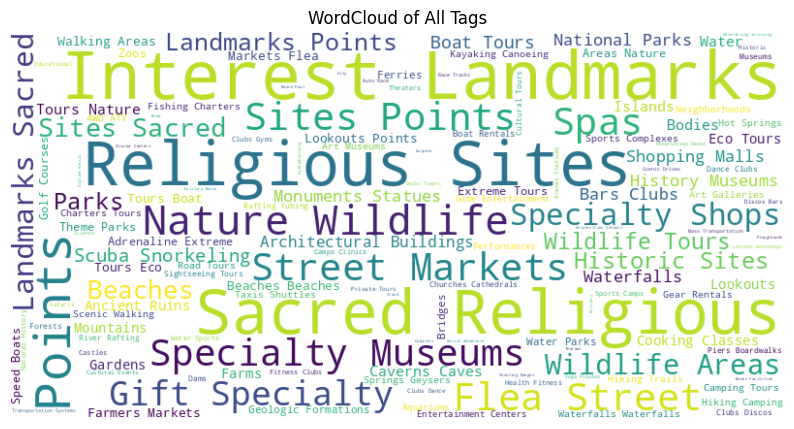

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# รวมข้อความทั้งหมดจากคอลัมน์ 'tags'
all_text = " ".join(combined_details_df['tags'].fillna(''))

# สร้าง WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# แสดง WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of All Tags")
plt.show()

In [70]:
# ตรวจสอบและแทนค่าที่เป็น NaN ในคอลัมน์ 'tags'
combined_details_df['tags'] = combined_details_df['tags'].fillna('')

# แปลงข้อความใน 'tags' ให้เป็นเมทริกซ์ TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(combined_details_df['tags'])

# สร้างโมเดล LDA เพื่อหา topics
lda_model = LatentDirichletAllocation(n_components=4, random_state=42)  # กำหนด 5 topics
lda_model.fit(X)

# ดึง top keywords ในแต่ละ topic
def print_topics(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_topics(lda_model, vectorizer.get_feature_names_out(), n_top_words=10)

# กำหนดกลุ่มให้แต่ละสถานที่
combined_details_df['topic'] = lda_model.transform(X).argmax(axis=1)



Topic 0:
sites sacred religious specialty spas museums flea street markets shops
Topic 1:
parks tours clubs national bars boat snorkeling scuba art ruins
Topic 2:
wildlife nature waterfalls areas water tours malls shopping farms lookouts
Topic 3:
of points landmarks interest beaches islands caverns caves hiking ferries


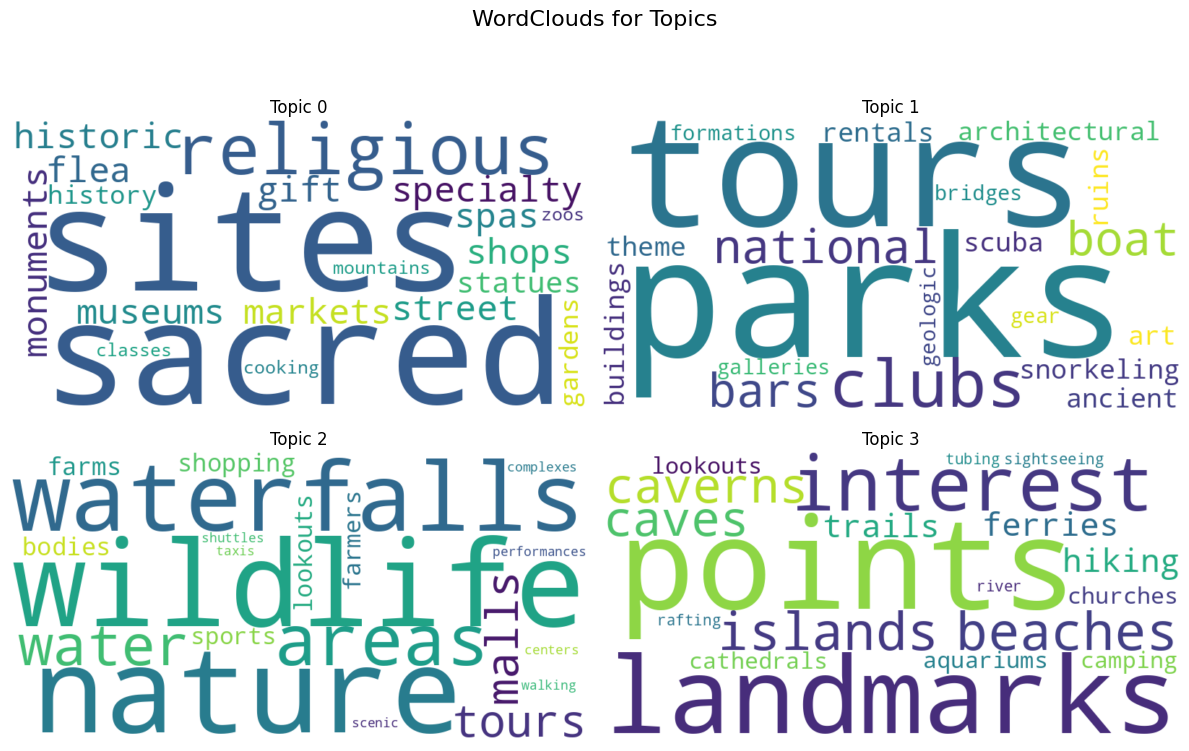

In [73]:
def get_topic_words(lda_model, feature_names, n_top_words=10):
    topic_words = []
    for topic_idx, topic in enumerate(lda_model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topic_words.append(" ".join(words))
    return topic_words

# Generate topic words from LDA model
topic_words = get_topic_words(lda_model, vectorizer.get_feature_names_out(), n_top_words=20)

# Function to plot WordClouds in a 2x2 grid
def plot_wordclouds_in_grid(topic_words, n_rows=2, n_cols=2):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
    fig.suptitle("WordClouds for Topics", fontsize=16)
    
    for idx, words in enumerate(topic_words):
        if idx < n_rows * n_cols:
            row, col = divmod(idx, n_cols)
            wordcloud = WordCloud(width=800, height=400, background_color='white').generate(words)
            axes[row, col].imshow(wordcloud, interpolation='bilinear')
            axes[row, col].axis('off')
            axes[row, col].set_title(f"Topic {idx}", fontsize=12)
        else:
            axes[row, col].axis('off')  # Turn off any extra axes
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to leave space for title
    plt.show()

# Plot the WordClouds in a 2x2 grid
plot_wordclouds_in_grid(topic_words, n_rows=2, n_cols=2)

In [71]:
combined_details_df[['name', 'tags', 'topic']]

,name,tags,topic
0,House of Opium,"History Museums, Specialty Museums",0
1,Opium Bar,Bars & Clubs,1
2,Wat Phra That Doi Saket,Sacred & Religious Sites,0
3,Mae Ping River Cruise,Boat Tours,1
4,Pai River,Bodies of Water,2
...,...,...,...
1761,Chao Lao Beach,Beaches,3
1762,Chao Lao Fish Bridge,Bridges,1
1763,Wat Burapa Temple,"Sacred & Religious Sites, Architectural Buildings",0
1764,Kung Wiman Beach,Beaches,3


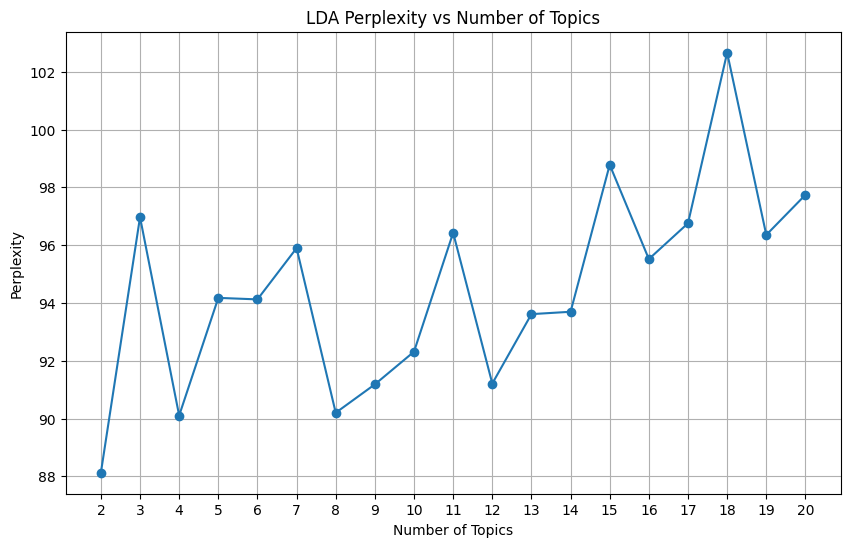

In [65]:
perplexities = []
topic_range = range(2, 21)  # กำหนดช่วงของจำนวนหัวข้อ (2 ถึง 20)

for n_topics in topic_range:
    lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda_model.fit(X)
    perplexities.append(lda_model.perplexity(X))

# การ Visualize ค่า Perplexity
plt.figure(figsize=(10, 6))
plt.plot(topic_range, perplexities, marker='o')
plt.title('LDA Perplexity vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity')
plt.xticks(topic_range)
plt.grid()
plt.show()